# 03 -- Processing: Aurora over the sites and the reference kinds

This workbook turns each site's cache into transfer functions. It applies the signs and the frame from
`decisions.csv`, scans each record for transients, builds the four references a site can be processed
against, writes one MTH5 per product with one run per kept stretch, runs Aurora, and writes an EDI and an
XML with the provenance of what was done.

Five kinds are built, and they are not alternatives to choose between here: every one of them is made, and
which of them becomes the product of record is workbook 06's question.

| word | what it is | code key | what it is for |
|---|---|---|---|
| single station | the site's own H and E | `single` | the control that says what a reference buys; biased down wherever the site's H noise is coherent with itself |
| remote site | one other site's H | `remote` | cancels the noise that is uncorrelated between the two sites; costs the variance of one more record |
| fleet stack | a coherence-weighted mean of several sites' H | `stack` | averages down each member's own noise, and needs the members aligned first |
| observatory | an INTERMAGNET one-second record | `obs` | far and quiet, and reaches the long periods |
| stack + observatory | the stack with the observatory as a member | `stack_obs` | the stack's short end with the observatory's long end |

The frame is fixed and stated in every file: the horizontal magnetic pair of each site is turned so its mean
Hy is zero, which takes out the fluxgate's hand-compass misalignment, and the IGRF declination is recorded
and not applied. Every member of a reference is turned into its own mean-field frame before it is stacked.

The record is never cut. A mask that removes a transient is applied by giving Aurora one run per kept
stretch of at least 3,600 s: cutting and concatenating puts a step at every join, and a step common to E, H
and the reference is coherent between them, so a robust regression fits it rather than down-weighting it.

Six checks state their failure criterion in bold above the cell and print a verdict below it. A check that
scores zero items prints UNJUDGED and counts as a failure. A criterion that is met is reported FAILED and is
not revised afterwards.

At 10 Hz Aurora reads about 8 per cent low at 4-32 s against its own 1 Hz product (AusLAMP Victoria,
2026-09-11). The 10 Hz products are made and each carries that sentence in its own file; they are not
spliced here, which is workbook 06's work.

In [1]:
# ---- parameters: change these and re-run the workbook ----
SURVEY = "queensland_phase2"  # any folder under surveys/: queensland_phase2 | queensland_phase3 | victoria
RUN = "first"                 # the run name; every site of one run lands in <site>/<RUN>_<stamp>/
SITES = "largest"# "all" | "largest" (the register's largest group) | a group name | ["Q49", "Q50"]
MAX_SITES = 5# 0 = every chosen site; a cap keeps an example short and names what it kept
WORK_ROOT = None              # None = survey.yaml work_root; every reference and product lands under it
KINDS = ["single", "remote", "stack", "obs", "stack_obs"]    # the code keys of the five reference kinds
RATES = [1]                   # [1] or [10]; a 10 Hz pass is one lane at 22-37 GB and 7-15 min a product
PARAMS = "kaiser20_75"        # the Aurora parameter set: kaiser20_50 | dpss4_75 | kaiser20_w512
LANES = 3                     # concurrent single-site subprocesses; 1 at 10 Hz, where a pass peaks at 37 GB
REDO = False                  # True remakes a product whose EDI is already on disk


In [2]:
# ---- the rule thresholds: a change here changes which reference every product was built on ----
COH_MIN = 0.5                 # the remote-site gate at 20-200 s; branches 1 and 2 need it
COH_RELAX = 0.3               # branch 3 relaxes to this where no clean candidate reaches COH_MIN
MIN_OVERLAP_DAYS = 20         # the overlap floor, taken with 0.75 x the days the target can use
STACK_CUTOFF = 0.5            # a member below this fleet coherence at 100-1000 s is refused
STACK_MAX = 8                 # the best this many members enter the stack
STACK_MIN = 2                 # fewer than this and the stack is refused: one member is a remote site renamed
EVENT_FRAC_MAX = 0.02         # clean: at most this fraction of the 600 s chunks flagged as events
BASELINE_MAX = 10             # clean: at most this multiple of the survey median baseline


## The survey, the sites and the run

Everything below runs on `surveys/<SURVEY>/` and writes under that survey's `work_root`. The run name and
the launch stamp name one folder per site, `<site>/<RUN>_<stamp>/`, so every product of one run sits
together with the provenance of the run that made it.

In [3]:
import os
import sys
import time
import warnings
warnings.filterwarnings("ignore")
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import Image, display

import auslamp_proc
from auslamp_proc import survey as SV, geo, observatory
from auslamp_proc.raw import cache
from auslamp_proc.process import KIND_WORD, aurora_run, edi as EDI, frame as FR, mth5_build
from auslamp_proc.process import provenance as PROV, references as REF, transients as TR

# aurora and mth5 re-arm loguru when they are first imported, which would put tens of thousands of INFO
# lines into this workbook. Import them, then drop the sinks. The "Window is longer than the time series"
# ERROR is expected on a short run: a one-hour run holds no complete window at the deep decimation levels.
aurora_run.silence_loggers()
import aurora

pd.set_option("display.width", 230)
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 400)

REPO = Path(auslamp_proc.__file__).resolve().parent.parent
sv = SV.load_survey(SURVEY)
if WORK_ROOT:
    sv.cfg["work_root"] = WORK_ROOT
WORK = Path(sv.cfg["work_root"])

def cached(site, rate=1):
    return (WORK / ("cache_%dhz" % rate) / ("%s.npz" % site)).exists()

# nothing here reads the raw tree: a site enters the run and the reference pool only where workbook 02 has
# built its cache, and the sites that have none are named rather than passed over
ALL_SITES = [s for s in sv.sites.site if cached(s)]
NO_CACHE = [s for s in sv.sites.site if not cached(s)]
CHOSEN, WHY = SV.select_sites(sv, SITES, 0)
CHOSEN = [s for s in CHOSEN if s in ALL_SITES]
if MAX_SITES and len(CHOSEN) > int(MAX_SITES):          # <- MAX_SITES caps the cached set, not the table
    WHY += "; capped at %d of %d with a cache" % (int(MAX_SITES), len(CHOSEN))
    CHOSEN = CHOSEN[:int(MAX_SITES)]
OUT = WORK / "survey"
OUT.mkdir(parents=True, exist_ok=True)
WRITTEN = []

# the pool thresholds are survey.yaml values; the parameter cell above governs this run of the workbook
sv.cfg.setdefault("pool", {})
sv.cfg["pool"]["event_frac_max"] = EVENT_FRAC_MAX
sv.cfg["pool"]["baseline_max"] = BASELINE_MAX

def store(rate, spec=None):
    """The reference store at one rate, carrying this workbook's thresholds."""
    return REF.Store(sv, ALL_SITES, rate=rate, coh_min=COH_MIN, coh_relax=COH_RELAX,
                     min_overlap_days=MIN_OVERLAP_DAYS, cutoff=STACK_CUTOFF, n_max=STACK_MAX,
                     n_min=STACK_MIN)

ST = store(RATES[0])
OBS = (sv.cfg.get("observatory") or {}).get("code", "")

# The stamp is the launch time in UTC of the whole run, and every site of one run shares it. A run is
# resumed rather than restarted: where <site>/<RUN>_<stamp>/ folders already exist the latest of their
# stamps is taken up again, so re-running this workbook finishes a run that was stopped part way and REDO
# False leaves the products already on disk alone. A RUN name with no folder yet mints a new stamp.
_stamps = sorted({p.name.split("_", 1)[1] for s in CHOSEN for p in (WORK / s).glob(RUN + "_*")
                  if p.is_dir()})
STAMP = _stamps[-1] if _stamps else datetime.now(timezone.utc).strftime("%Y%m%d_%H%M")

print("survey       %s" % sv.cfg["name"])
print("work root    %s" % WORK)
print("sites        %d chosen from %s" % (len(CHOSEN), WHY))
print("             %s" % " ".join(CHOSEN))
print("pool from    %d of the %d sites in sites.csv, the ones with a 1 Hz cache (a reference may come from "
      "a site this run does not process)" % (len(ALL_SITES), len(sv.sites)))
if NO_CACHE:
    print("no cache     %s -- run workbook 02 over them to bring them into the pool" % " ".join(NO_CACHE))
print("kinds        %s" % ", ".join("%s (%s)" % (KIND_WORD[k], k) for k in KINDS))
print("rates        %s Hz, parameter set %s, %d lane(s)" % (", ".join(str(r) for r in RATES), PARAMS, LANES))
print("run          %s_%s  ->  <work_root>/<site>/  (%s)"
      % (RUN, STAMP, "resumed: the folders of this run name already exist" if _stamps else "a new run"))
print("engine       Aurora %s, mth5 %s" % (aurora.__version__, __import__("mth5").__version__))
print("observatory  %s at %s" % (OBS, (sv.cfg.get("observatory") or {}).get("archive", "")))


survey       queensland_phase2
work root    E:\MT_Timeseries_DATA\MT_AusLAMP_QLD\Processing_WB\phase2
sites        5 chosen from register group G01 (18 members, common window 54.71 d); capped at 5 of 13 with a cache
             Q82 Q81N Q80N Q79N Q78N
pool from    13 of the 18 sites in sites.csv, the ones with a 1 Hz cache (a reference may come from a site this run does not process)
no cache     Q46N Q47N Q48N Q56N Q57N -- run workbook 02 over them to bring them into the pool
kinds        single station (single), remote site (remote), fleet stack (stack), observatory (obs), stack + observatory (stack_obs)
rates        1 Hz, parameter set kaiser20_75, 3 lane(s)
run          first_20260916_1056  ->  <work_root>/<site>/  (resumed: the folders of this run name already exist)
engine       Aurora 0.6.2, mth5 0.6.9
observatory  CTA at E:/MT_Timeseries_DATA/Geomagnetic_Observatory_Data/INTERMAGNET_1sec


## The sites and their decisions

The `sites.csv` facts each product's header carries, and the `decisions.csv` row it was built under. A sign
cell reading `decide` is used as +1 and recorded as undecided: the product is made, its EDI carries a
`signs_undecided` line naming the channels, and its provenance carries a caveat. Nothing is decided silently.

`remote_site` is the analyst's choice of remote where it names a site; where it reads `decide` the
five-branch rule below chooses one. `stack_members`, `rot_regimes` and `rot_drop` work the same way: a value
governs, `decide` hands the question to the rule.

In [4]:
rows = []
for s in CHOSEN:
    r = sv.site(s)
    d = sv.decision(s)
    signs = {c: FR.read_sign(d.get(FR.SIGN_COLUMN[c])) for c in FR.CHANNELS}
    rows.append(dict(site=s, days=r.days, lat=r.lat, lon=r.lon, dipole_n_m=r.dipole_n_m,
                     dipole_e_m=r.dipole_e_m, declination_deg=r.declination_deg,
                     signs=" ".join("%s%+d" % (c, signs[c][0]) for c in FR.CHANNELS),
                     undecided=" ".join(c for c in FR.CHANNELS if not signs[c][1]) or "none",
                     remote_site=d.get("remote_site", ""), stack_members=d.get("stack_members", ""),
                     rot_regimes=d.get("rot_regimes", ""), rot_drop=d.get("rot_drop", "")))
tab = pd.DataFrame(rows)
print(tab.to_string(index=False))
print()
n_und = int((tab.undecided != "none").sum())
print("%d of %d sites carry at least one undecided sign; every such product says so in its own EDI"
      % (n_und, len(tab)))
print("%d sites name a remote in decisions.csv, %d leave it to the rule"
      % (int((~tab.remote_site.str.lower().isin(["decide", "", "nan"])).sum()),
         int(tab.remote_site.str.lower().isin(["decide", "", "nan"]).sum())))
print("%d sites name their own stack members; the rest take the clean pool of their overlap group"
      % int((~tab.stack_members.str.lower().isin(["decide", "", "nan"])).sum()))
print()
print("the five kinds, as words and as the code keys that appear in file names")
print(pd.DataFrame([dict(word=KIND_WORD[k], key=k) for k in REF.KINDS_WITH_STORE +
                    ("single",)]).to_string(index=False))


site   days       lat       lon dipole_n_m dipole_e_m declination_deg                    signs undecided remote_site stack_members rot_regimes rot_drop
 Q82 65.625 -28.01858 146.00334        9.2        9.4            9.04 Hx+1 Hy+1 Hz+1 Ex-1 Ey-1  Hx Hy Hz        Q69N        decide      decide   decide
Q81N 65.785   -28.155 145.00902         11       12.3           8.749 Hx+1 Hy+1 Hz+1 Ex-1 Ey-1  Hx Hy Hz         Q82        decide      decide   decide
Q80N 65.635 -27.98869 143.91486        9.2        9.5           8.342 Hx+1 Hy+1 Hz+1 Ex-1 Ey-1  Hx Hy Hz        Q79N        decide      decide   decide
Q79N  65.64 -27.72751 142.98546         11         11           7.967 Hx+1 Hy+1 Hz+1 Ex-1 Ey-1  Hx Hy Hz        Q78N        decide      decide   decide
Q78N 65.632  -28.0558 142.37597       10.9       10.5           7.844 Hx+1 Hy+1 Hz+1 Ex-1 Ey-1  Hx Hy Hz        Q79N        decide      decide   decide

5 of 5 sites carry at least one undecided sign; every such product says so in its own E

## The frame

Two things happen to a record before anything is estimated from it, in this order. Each channel is
multiplied by its `decisions.csv` sign. Then the horizontal magnetic pair is turned by
theta = atan2(mean Hy, mean Hx), which puts the mean Hy at zero; the electric lines are left as laid.

The rotation is a rigid turn of the pair, so it cannot change the total horizontal field at any sample: that
is what makes it testable. The angle is a property of how the sensor was laid, not of the field, and it is
recorded in every product as `h_rotation_deg`. The IGRF declination is recorded beside it and not applied --
turning by IGRF as well would rotate the record twice.

**This check fails if any site's rotated record has |mean Hy| > 1e-6 nT or a changed |H| at any sample.**
|H| is compared before and after the turn, sample by sample, on the same float64 arithmetic the processing
uses; the bound on the comparison is 1e-6 nT, which is eleven orders of magnitude below the 50,000 nT the
field itself carries.

In [5]:
frame_rows = []
for s in CHOSEN:
    z = np.load(WORK / "cache_1hz" / ("%s.npz" % s), allow_pickle=False)
    h = {c: np.asarray(z[c], float) for c in ("Hx", "Hy")}
    z.close()
    d = sv.decision(s)
    h, applied, undecided = FR.apply_signs(h, d)
    before = np.hypot(h["Hx"], h["Hy"])
    turned, ang = FR.rotate_to_mean_field(h, regimes=FR.parse_regimes(d.get("rot_regimes")),
                                          drop=FR.parse_regimes(d.get("rot_drop")), fs=1.0)
    after = np.hypot(turned["Hx"], turned["Hy"])
    g = np.isfinite(before) & np.isfinite(after)
    all_signs = {c: FR.read_sign(d.get(FR.SIGN_COLUMN[c])) for c in FR.CHANNELS}
    frame_rows.append(dict(site=s, angle_deg=(ang if isinstance(ang, float) else "%d regimes" % len(ang)),
                           declination_deg=sv.site(s).declination_deg,
                           mean_Hy_nT=float(np.nanmean(turned["Hy"])),
                           worst_dH_nT=float(np.nanmax(np.abs(after[g] - before[g]))) if g.any() else np.nan,
                           samples=int(g.sum()),
                           H_signs=" ".join("%s%+d" % (c, applied[c]) for c in ("Hx", "Hy")),
                           undecided=" ".join(c for c in FR.CHANNELS if not all_signs[c][1]) or "none"))
    del h, turned, before, after
fr = pd.DataFrame(frame_rows)
print(fr.to_string(index=False))
print()
print("the angle is the sensor's own misalignment, and the declination beside it is the field's; the two "
      "are different quantities and neither is the other")

bad_hy = fr[fr.mean_Hy_nT.abs() > 1e-6]
bad_h = fr[fr.worst_dH_nT > 1e-6]
print()
if not len(fr) or not fr.samples.sum():
    print("VERDICT: UNJUDGED -- no site produced a rotated record to score")
elif len(bad_hy) or len(bad_h):
    print("VERDICT: FAIL -- %d of %d sites leave a mean Hy above 1e-6 nT (%s); %d change |H| by more than "
          "1e-6 nT (%s)"
          % (len(bad_hy), len(fr), "; ".join("%s %.3g nT" % (r.site, r.mean_Hy_nT)
                                             for r in bad_hy.itertuples()) or "none",
             len(bad_h), "; ".join("%s %.3g nT" % (r.site, r.worst_dH_nT)
                                   for r in bad_h.itertuples()) or "none"))
else:
    print("VERDICT: PASS -- all %d sites rotate to a mean Hy of at most %.3g nT and change |H| by at most "
          "%.3g nT over %d samples; the angles run %.2f to %.2f deg and the declinations %.2f to %.2f deg"
          % (len(fr), fr.mean_Hy_nT.abs().max(), fr.worst_dH_nT.max(), int(fr.samples.sum()),
             pd.to_numeric(fr.angle_deg, errors="coerce").min(),
             pd.to_numeric(fr.angle_deg, errors="coerce").max(),
             pd.to_numeric(fr.declination_deg, errors="coerce").min(),
             pd.to_numeric(fr.declination_deg, errors="coerce").max()))


site  angle_deg declination_deg    mean_Hy_nT  worst_dH_nT  samples   H_signs undecided
 Q82     0.1005            9.04  0.000000e+00 7.275958e-12  5670000 Hx+1 Hy+1  Hx Hy Hz
Q81N   -10.4559           8.749  4.037360e-13 7.275958e-12  5683860 Hx+1 Hy+1  Hx Hy Hz
Q80N     1.8285           8.342 -6.831972e-14 7.275958e-12  5670840 Hx+1 Hy+1  Hx Hy Hz
Q79N     1.4880           7.967 -3.152951e-14 7.275958e-12  5671320 Hx+1 Hy+1  Hx Hy Hz
Q78N     2.0564           7.844  1.051117e-13 7.275958e-12  5670600 Hx+1 Hy+1  Hx Hy Hz

the angle is the sensor's own misalignment, and the declination beside it is the field's; the two are different quantities and neither is the other

VERDICT: PASS -- all 5 sites rotate to a mean Hy of at most 4.04e-13 nT and change |H| by at most 7.28e-12 nT over 28366620 samples; the angles run -10.46 to 2.06 deg and the declinations 7.84 to 9.04 deg


## The clean pool

A site may reference another only if its own magnetic record is fit to. The tail scan walks each rotated
record in 600 s chunks and takes the median band power of Hx, Hy, Ex and Ey over 20-200 s
(`auslamp_proc.process.transients.scan`, survey.yaml `pool`), and two tests are read off it.

The event test is fleet-normalised. A chunk is an event where the site's own power exceeds 100 times its own
median AND the rest of the fleet does not see the same thing: either fewer than 3 other sites were recording
then, or this site runs more than 10 times the median of the others. A substorm lifts every site in the
array within the same ten minutes and is signal; a power-cycle or a vehicle lifts one, and only the second is
a fault. The site's own median cannot tell them apart.

The baseline test catches the other failure: a site that never spikes because it is loud all the time. The
denominator is one median over every site with a scan, so the level is a property of the instrument and the
band rather than of whoever was deployed alongside.

The band is 20-200 s and not the 2-20 s the campaign scan reads at 10 Hz. A 1 Hz cache is decimated from
10 Hz, so its 2-20 s band sits on the anti-alias filter's roll-off and reads each unit's own noise floor:
over these 23 fluxgates the 2-20 s chunk medians span five decades, where the 20-200 s medians hold inside a
factor of 10 at 22 of the 23. A baseline that is not comparable between sites cannot be judged against a
survey median.

    clean = event fraction <= EVENT_FRAC_MAX and baseline <= BASELINE_MAX x the survey median

**This check fails if the scan is UNJUDGED at any site, that is if no chunk was scored there.**

In [6]:
scan_rows = []
for s in ALL_SITES:                              # <- every site in sites.csv: the pool is not the chosen set
    t = time.time()
    if TR.load_series(s, WORK) is None:
        t0, arrays, meta = cache.load(s, WORK, 1)
        d = sv.decision(s)
        arrays, _a, _u = FR.apply_signs(arrays, d)
        arrays, _ang = FR.rotate_to_mean_field(arrays, regimes=FR.parse_regimes(d.get("rot_regimes")),
                                               drop=FR.parse_regimes(d.get("rot_drop")), fs=1.0)
        row = TR.scan(s, t0, arrays, WORK, fs=1.0, cfg=sv.cfg)
        del arrays
        print("%-9s scanned in %5.1f s" % (s, time.time() - t), flush=True)
    else:
        row = TR.summarise(s, *TR.load_series(s, WORK))
    scan_rows.append(row)

pool, pool_table = ST.clean_pool(force=True)
base = TR.survey_baseline(ALL_SITES, WORK)
scan_t = pd.DataFrame(scan_rows).merge(pool_table, on="site")
print()
print("the survey median baseline is %.4g nT^2/Hz at 20-200 s over %d sites with a scan"
      % (base, len(scan_t)))
print(scan_t[["site", "chunks", "days", "Hx_median", "Hy_median", "event_frac", "baseline", "clean",
              "reason"]].round(4).to_string(index=False))
print()
print("the pool (%d of %d): %s" % (len(pool), len(scan_t), " ".join(pool)))
print("excluded, with the reason:")
for r in pool_table[~pool_table.clean].itertuples():
    print("   %-9s %s" % (r.site, r.reason))

unjudged = pool_table[~pool_table.judged]
print()
if not len(pool_table):
    print("VERDICT: UNJUDGED -- no site was scanned, so the pool scored nothing")
elif len(unjudged):
    print("VERDICT: FAIL -- the scan scored no chunk at %d of %d sites (%s)"
          % (len(unjudged), len(pool_table), ", ".join(unjudged.site)))
else:
    print("VERDICT: PASS -- every one of the %d sites was scored on at least one chunk, the thinnest being "
          "%d chunks at %s; %d sites are clean at events <= %s and baseline <= %sx, and the %d excluded are "
          "each named with the limb they failed"
          % (len(pool_table), int(scan_t.chunks.min()), scan_t.site[scan_t.chunks.idxmin()],
             len(pool), EVENT_FRAC_MAX, BASELINE_MAX, len(pool_table) - len(pool)))



the survey median baseline is 0.03448 nT^2/Hz at 20-200 s over 13 sites with a scan
site  chunks  days  Hx_median  Hy_median  event_frac  baseline  clean                                                               reason
Q58N    9470 65.76     0.0277     0.0087      0.0050    0.8036   True                                                                     
Q59N    9469 65.76     0.0321     0.0103      0.0243    0.9310  False                                         event fraction 0.0243 > 0.02
Q66N    9470 65.76     0.0509     0.0121      0.0116    1.4774   True                                                                     
Q67N    9470 65.76     0.4547     0.0147      0.1866   13.1844  False event fraction 0.1866 > 0.02; baseline 13.2x > 10x the survey median
Q68N    9472 65.78     0.0312     0.0096      0.0013    0.9044   True                                                                     
Q69N    9471 65.77     0.0332     0.0086      0.0041    0.9634   True            

## The remote site

Every candidate in the target's own overlap group is scored: the distance in km, the usable overlap in days,
its event fraction and baseline from the scan above, and the event-free 20-200 s coherence of the pair. The
coherence is a chunk median and never one pass over the whole record -- one transient inside one Welch
segment otherwise takes a whole record's score to the floor -- and nothing is concatenated: the uncut overlap
is walked in whole 1,024 s segments and a segment is used only where the mask is true right through it, so
the estimator never reads a join it made itself.

A candidate is scored only where its overlap reaches min(MIN_OVERLAP_DAYS, 0.75 x the days the target can
use). The days the target can use, not the length of its cache: a cache is as long as the logger ran, not as
long as the magnetics are sound.

The choice is then the five-branch rule, and the branch is recorded in the product:

1. clean, coh >= COH_MIN, overlap >= 90 per cent -- the nearest of them
2. clean, coh >= COH_MIN -- the longest overlap
3. clean, coh >= COH_RELAX -- the most coherent
4. coh >= COH_MIN but not clean -- the fewest events
5. none of the above -- the nearest by km

Where `decisions.csv` names a remote, that site is used and the rule's own choice is printed beside it. The
two agreeing is a reading and not a criterion: the campaign chose its remotes on a deployment sheet and a
different coherence estimator, and this rule is an independent computation.

**This check fails if any chosen remote has no overlap with its target or is not in the target's overlap
group.**

In [7]:
groups = ST.groups()
remote_rows, cand_tables = [], {}
for s in CHOSEN:
    scores = ST.score_candidates(s)
    cand_tables[s] = scores
    ch = ST.remote_site(s, scores=scores)
    ov = ST.overlap(s, ch["name"]) if ch.get("name") else None
    coh = ch.get("coh")
    if coh is None and ch.get("name") and ov is not None:
        # a remote decisions.csv names from outside the clean pool is not in the candidate table, so it
        # carries no score there; it is measured here on the same rule so the column is never empty
        coh = round(float(ST.pair_coherence(s, ch["name"])["coh"]), 3)
    remote_rows.append(dict(site=s, campaign_remote=str(sv.decision(s).get("remote_site", "")),
                            rule_remote=ch.get("rule_name"), rule_branch=ch.get("rule_branch"),
                            rule_coh=ch.get("rule_coh"), chosen=ch.get("name"),
                            source=ch.get("source"), coh=coh,
                            overlap_days=(round((ov[1] - ov[0]) / 86400.0, 2) if ov else 0.0),
                            group=groups.get(s, ""), remote_group=groups.get(ch.get("name"), ""),
                            n_candidates=len(ch.get("candidates", [])), reason=ch.get("reason", "")[:150]))
rem = pd.DataFrame(remote_rows)
print("the candidates of %s, the first of the chosen set" % CHOSEN[0])
print(cand_tables[CHOSEN[0]].round(4).to_string(index=False))
print()
print(rem[["site", "campaign_remote", "rule_remote", "rule_branch", "rule_coh", "chosen", "source",
           "coh", "overlap_days", "group", "remote_group"]].to_string(index=False))
print()
differ = rem[(rem.campaign_remote.str.lower() != "decide") & (rem.campaign_remote != rem.rule_remote)]
print("the campaign's remote and the rule's choice differ at %d of %d sites (a reading, not a criterion):"
      % (len(differ), len(rem)))
for r in differ.itertuples():
    print("   %-9s campaign %-8s rule %-8s (branch %s, coh %s)"
          % (r.site, r.campaign_remote, r.rule_remote, r.rule_branch, r.rule_coh))
print()
print("the branch the rule took, over the chosen set")
print(rem.rule_branch.value_counts().sort_index().to_string())
print()
for r in rem.itertuples():
    print("   %-9s %s" % (r.site, r.reason))

no_ov = rem[rem.overlap_days <= 0]
wrong_group = rem[(rem.group != "") & (rem.group != rem.remote_group)]
print()
if not len(rem):
    print("VERDICT: UNJUDGED -- no site was offered a remote")
elif len(no_ov) or len(wrong_group) or rem.chosen.isna().any():
    print("VERDICT: FAIL -- %d of %d chosen remotes do not overlap their target (%s); %d sit outside the "
          "target's overlap group (%s); %d sites were offered no remote at all (%s)"
          % (len(no_ov), len(rem), ", ".join(no_ov.site) or "none",
             len(wrong_group), "; ".join("%s -> %s (%s vs %s)" % (r.site, r.chosen, r.group, r.remote_group)
                                         for r in wrong_group.itertuples()) or "none",
             int(rem.chosen.isna().sum()), ", ".join(rem.site[rem.chosen.isna()]) or "none"))
else:
    print("VERDICT: PASS -- all %d chosen remotes overlap their target, the shortest by %.2f d at %s, and "
          "every one sits in the target's own overlap group; %d came from decisions.csv and %d from the rule"
          % (len(rem), rem.overlap_days.min(), rem.site[rem.overlap_days.idxmin()],
             int((rem.source == "decisions.csv").sum()), int((rem.source != "decisions.csv").sum())))


the candidates of Q82, the first of the chosen set
name    km  overlap_days  overlap_frac  event_frac  baseline  clean   coh  chunks   ok why  own_days  min_overlap_days  chunk_days  clean_days  mask_frac
Q58N 210.4          60.9         0.928      0.0050       0.8   True 0.666     122 True          65.6              20.0         0.5        61.0     0.0063
Q66N 390.4          62.8         0.958      0.0116       1.5   True 0.525     126 True          65.6              20.0         0.5        63.0     0.0134
Q68N 228.5          61.9         0.943      0.0013       0.9   True 0.683     124 True          65.6              20.0         0.5        62.0     0.0027
Q69N 166.7          61.7         0.940      0.0041       1.0   True 0.639     124 True          65.6              20.0         0.5        62.0     0.0056
Q78N 356.0          63.6         0.970      0.0098       0.9   True 0.585     127 True          65.6              20.0         0.5        63.5     0.0104
Q79N 298.4          63.8 

## The fleet stack

A member's weight is its median coherence with the FLEET at 100-1000 s, and never its coherence with the
target. Whether a reference is a good measurement of the regional field is a question about the reference
and the field; weighting a member by how well it agrees with the target puts the target's own noise into
its reference (Ben's rule, 2026-09-06). The fleet table below is one median per member over its pairs with
the rest of the pool, and it is the same table for every target.

Members below STACK_CUTOFF are refused, the best STACK_MAX are kept, and a stack with fewer than STACK_MIN
members is refused outright: a one-member stack is a remote site renamed.

Each member is aligned first. The lag is the median 5-20 s cross-correlation over up to eight event-free
two-day windows spread across the record, and it is accepted only where it is one constant, spread at most
1.0 s: no single shift fixes a free-running clock. A member whose lag cannot be measured or is not one
constant is kept at lag 0 with the reason recorded, because these are GPS-disciplined loggers.

Each member is then demeaned over its own finite samples, and a sample where a member is NaN does not add to
that member's weight there, so the mean is over whoever is sound and the weights renormalise per sample.
Where no member is sound the stack is zero and its mask is False: a zero reference contributes nothing to
either the cross- or the auto-spectrum, so those windows drop out of the estimate instead of biasing it.

**This check fails if any stack carries a member weighted by its coherence with the TARGET rather than the
fleet, or a member outside the pool.** The first limb is scored by recomputing one site's weights from the
fleet coherence table printed above and comparing them with the weights in that site's own sidecar, and by
comparing the same weights against the target coherences of the candidate table: a weight that matches the
target column and not the fleet column is the wrong rule.

In [8]:
weights, pairs = ST.fleet_weights()
fleet = pd.DataFrame([dict(member=k, fleet_coh_100_1000s=v,
                           pairs=sum(1 for p in pairs if k in p.split(":")))
                      for k, v in sorted(weights.items())])
print("the fleet coherence of every pool member at 100-1000 s, the median over its pairs with the rest")
print(fleet.to_string(index=False))
print()
print("the pairs it is the median of")
pf = pd.DataFrame([dict(pair=k, coh=v["coh"], chunks=v["chunks"]) for k, v in sorted(pairs.items())])
print(pf.to_string(index=False))

stack_rows, member_rows, stacks = [], [], {}
for s in CHOSEN:
    kept, lags, refused, notes = ST.stack_members(s)
    stacks[s] = (kept, lags, refused, notes)
    stack_rows.append(dict(site=s, n_members=len(kept),
                           members=" ".join(kept), weights=" ".join("%.3f" % v for v in kept.values()),
                           lags_s=" ".join("%+.2f" % lags.get(d, 0.0) for d in kept),
                           refused=len(refused), notes=len(notes)))
    for d, w in kept.items():
        member_rows.append(dict(site=s, member=d, weight=w, lag_s=lags.get(d, 0.0),
                                note=notes.get(d, ""), in_pool=d in pool))
    for d, why in sorted(refused.items()):
        member_rows.append(dict(site=s, member=d, weight=None, lag_s=None, note=why, in_pool=d in pool))
sk = pd.DataFrame(stack_rows)
mem = pd.DataFrame(member_rows)
print()
print(sk.to_string(index=False))
print()
print("every member and every refusal, per site")
print(mem.to_string(index=False))
print()
refused_sites = sk[sk.n_members < STACK_MIN]
print("stacks refused for want of members: %s"
      % (", ".join("%s (%d < %d)" % (r.site, r.n_members, STACK_MIN)
                   for r in refused_sites.itertuples()) or "none"))

# limb A, recomputed: the weight of every member has to be the fleet value and not the target value
probe = CHOSEN[0]
kept = stacks[probe][0]
cand = cand_tables[probe].set_index("name")
recomputed = {d: weights.get(d) for d in kept}
target_coh = {d: (float(cand.loc[d, "coh"]) if d in cand.index and cand.loc[d, "coh"] is not None
                  else None) for d in kept}
print()
print("%s: the weight in the store against the fleet table and against this site's own target coherence"
      % probe)
print(pd.DataFrame([dict(member=d, in_store=kept[d], fleet_table=recomputed[d], target_coh=target_coh[d])
                    for d in kept]).to_string(index=False))
wrong_rule = [d for d in kept if recomputed[d] is None or abs(kept[d] - recomputed[d]) > 1e-6]
looks_like_target = [d for d in kept if target_coh[d] is not None and abs(kept[d] - target_coh[d]) < 1e-6
                     and (recomputed[d] is None or abs(target_coh[d] - recomputed[d]) > 1e-6)]
outside = sorted(set(mem.member[(mem.weight.notna()) & (~mem.in_pool)]))
scored = int(mem.weight.notna().sum())
print()
if not scored:
    print("VERDICT: UNJUDGED -- no stack carries a member, so no weight was scored")
elif wrong_rule or looks_like_target or outside:
    print("VERDICT: FAIL -- %d of %s's %d members do not carry the fleet weight (%s); %d carry the target "
          "coherence instead (%s); %d members over all %d stacks sit outside the clean pool (%s)"
          % (len(wrong_rule), probe, len(kept), ", ".join(wrong_rule) or "none",
             len(looks_like_target), ", ".join(looks_like_target) or "none",
             len(outside), len(sk), ", ".join(outside) or "none"))
else:
    print("VERDICT: PASS -- all %d of %s's members carry the fleet coherence recomputed from the table "
          "above to within 1e-6 and none carries its target coherence (which differs by %.3f to %.3f), and "
          "every one of the %d members over %d stacks is in the %d-site clean pool"
          % (len(kept), probe, min(abs(kept[d] - target_coh[d]) for d in kept if target_coh[d] is not None),
             max(abs(kept[d] - target_coh[d]) for d in kept if target_coh[d] is not None),
             scored, len(sk), len(pool)))


the fleet coherence of every pool member at 100-1000 s, the median over its pairs with the rest
member  fleet_coh_100_1000s  pairs
  Q58N               0.9682      6
  Q66N               0.9650      6
  Q68N               0.9817      6
  Q69N               0.9786      6
  Q78N               0.9737      6
  Q79N               0.9731      6
   Q82               0.9560      6

the pairs it is the median of
     pair    coh  chunks
Q58N:Q66N 0.9610     127
Q58N:Q68N 0.9866     130
Q58N:Q69N 0.9845     130
Q58N:Q78N 0.9694     126
Q58N:Q79N 0.9665     126
 Q58N:Q82 0.9669     122
Q66N:Q68N 0.9737     130
Q66N:Q69N 0.9633     129
Q66N:Q78N 0.9734     130
Q66N:Q79N 0.9667     130
 Q66N:Q82 0.9342     126
Q68N:Q69N 0.9873     131
Q68N:Q78N 0.9837     128
Q68N:Q79N 0.9796     128
 Q68N:Q82 0.9628     124
Q69N:Q78N 0.9740     128
Q69N:Q79N 0.9831     127
 Q69N:Q82 0.9537     123
Q78N:Q79N 0.9822     131
 Q78N:Q82 0.9583     127
 Q79N:Q82 0.9420     128



site  n_members                           members                                   weights                                    lags_s  refused  notes
 Q82          6     Q68N Q69N Q78N Q79N Q58N Q66N       0.982 0.979 0.974 0.973 0.968 0.965       -0.26 -0.25 +0.05 +0.17 -0.31 +0.00        0      1
Q81N          7 Q68N Q69N Q78N Q79N Q58N Q66N Q82 0.982 0.979 0.974 0.973 0.968 0.965 0.956 +0.00 +0.00 +0.00 +0.00 +0.00 +0.00 +0.00        0      6
Q80N          7 Q68N Q69N Q78N Q79N Q58N Q66N Q82 0.982 0.979 0.974 0.973 0.968 0.965 0.956 -0.29 -0.56 +0.03 +0.00 -0.40 +0.00 -0.10        0      2
Q79N          6      Q68N Q69N Q78N Q58N Q66N Q82       0.982 0.979 0.974 0.968 0.965 0.956       -0.18 -0.31 +0.12 -0.47 +0.00 -0.17        0      1
Q78N          6      Q68N Q69N Q79N Q58N Q66N Q82       0.982 0.979 0.973 0.968 0.965 0.956       -0.32 -0.51 -0.12 -0.43 -0.05 -0.05        0      0

every member and every refusal, per site
site member  weight  lag_s                               

## The observatory

The INTERMAGNET one-second record of the survey's own observatory, read out of the archive over each site's
window and turned into the mean-field frame of that window like any other member. It is never shifted: a
delay on a single reference cancels exactly in Z, so shifting it would change nothing and leaving it alone
keeps that invariance available as a check.

Its weight in the stack + observatory is measured on the same rule as a site member's -- the median
coherence with the pool at 100-1000 s -- so it enters at a weight on the members' own scale rather than at
its agreement with any one target.

The coherence of each site with the observatory is a reading. It says how much of the site's long-period
field the observatory shares from several hundred kilometres away, which is what the observatory kind can
buy and what it cannot: at the short end a distant observatory shares almost nothing.

In [9]:
w_obs, obs_pairs = ST.observatory_weight(OBS)
print("observatory %s, %s" % (OBS, geo.OBSERVATORIES.get(OBS, ("", 0, 0))[0]))
print("its fleet weight at 100-1000 s is %s, the median over %d pool members"
      % (w_obs, sum(1 for v in obs_pairs.values() if v is not None)))
print()
obs_rows = []
for s in CHOSEN:
    p = ST.path("obs", s).with_suffix(".json")
    km = geo.distance_km(ST.position(s), OBS)
    # a site outside the pool has no pair in the weight table; it is measured here so the reading covers
    # every site this run processes
    c = obs_pairs.get(s)
    chunks = None
    if c is None:
        r = ST.site_observatory_coh(s, OBS)
        c = None if not np.isfinite(r["coh"]) else round(float(r["coh"]), 4)
        chunks = r["chunks"]
    obs_rows.append(dict(site=s, km=round(km, 1), coh_100_1000s=c, in_pool=s in pool,
                         chunks=chunks, built=p.exists()))
ob = pd.DataFrame(obs_rows)
print(ob.to_string(index=False))
print()
print("stack + observatory: the stack's members with %s added at weight %s and lag 0" % (OBS, w_obs))
print(pd.DataFrame([dict(site=s, members=" ".join(list(stacks[s][0]) + ([OBS] if w_obs else [])),
                         n=len(stacks[s][0]) + (1 if w_obs else 0)) for s in CHOSEN]).to_string(index=False))


observatory CTA, Charters Towers, Australia
its fleet weight at 100-1000 s is 0.8282, the median over 7 pool members



site    km  coh_100_1000s  in_pool  chunks  built
 Q82 882.0         0.8182     True     NaN   True
Q81N 905.8         0.7729    False    66.0   True
Q80N 910.0         0.8345    False    66.0   True
Q79N 912.2         0.8272     True     NaN   True
Q78N 969.5         0.8282     True     NaN   True

stack + observatory: the stack's members with CTA added at weight 0.8282 and lag 0
site                               members  n
 Q82     Q68N Q69N Q78N Q79N Q58N Q66N CTA  7
Q81N Q68N Q69N Q78N Q79N Q58N Q66N Q82 CTA  8
Q80N Q68N Q69N Q78N Q79N Q58N Q66N Q82 CTA  8
Q79N      Q68N Q69N Q78N Q58N Q66N Q82 CTA  7
Q78N      Q68N Q69N Q79N Q58N Q66N Q82 CTA  7


## The references written to the store

Every reference is written once per rate to `<work_root>/references/<rate>hz/<kind>_<site>.npz`, with a
sidecar naming its members, their weights and lags, the refusals with their reasons, the frame and the time
it was built. A pass reads the store; it never rebuilds a reference of its own, so two products of the same
kind are built on the same array.

A 10 Hz store re-reads the 1 Hz specification -- the same pool, the same remote, the same members, weights
and lags -- on the 10 Hz grid after a spike screen. The decisions are made where they can be measured.

In [10]:
built = {}
for rate in RATES:
    st = ST if rate == RATES[0] else store(rate)
    spec = None
    if rate != 1:
        spec = store(1)                     # <- the 10 Hz store takes its decisions from the 1 Hz one
    t = time.time()
    kinds = tuple(k for k in KINDS if k in REF.KINDS_WITH_STORE)
    got = REF.build_store(sv, CHOSEN, rate=rate, kinds=kinds, verbose=False, spec_store=spec, store=st)
    built[rate] = got
    print("%d Hz: %d sites, %d references, %.1f s" % (rate, len(got),
                                                      sum(len(v) for v in got.values()), time.time() - t))
    rows = []
    for s, d in sorted(got.items()):
        for k, info in sorted(d.items()):
            rows.append(dict(site=s, kind=k, coverage=info.get("coverage"),
                             members=" ".join(m["name"] for m in (info.get("members") or [])
                                              if m.get("role") != "refused"),
                             error=str(info.get("error", ""))[:90]))
    print(pd.DataFrame(rows).to_string(index=False))


1 Hz: 5 sites, 20 references, 0.0 s
site      kind  coverage           members error
Q78N       obs    0.9999               CTA      
Q78N    remote    0.9982              Q79N      
Q78N     stack    0.9982          Q79N Q82      
Q78N stack_obs    1.0000      Q79N Q82 CTA      
Q79N       obs    0.9999               CTA      
Q79N    remote    0.9981              Q78N      
Q79N     stack    0.9988          Q78N Q82      
Q79N stack_obs    1.0000      Q78N Q82 CTA      
Q80N       obs    0.9999               CTA      
Q80N    remote    0.9841              Q79N      
Q80N     stack    1.0000     Q78N Q79N Q82      
Q80N stack_obs    1.0000 Q78N Q79N Q82 CTA      
Q81N       obs    0.9999               CTA      
Q81N    remote    0.9866               Q82      
Q81N     stack    1.0000     Q78N Q79N Q82      
Q81N stack_obs    1.0000 Q78N Q79N Q82 CTA      
 Q82       obs    0.9999               CTA      
 Q82    remote    0.9403              Q69N      
 Q82     stack    0.9714         

## The bands and the parameter set

The band file's lines are FFT harmonics of the **window**, not of the record, so a file read at another
window length names different periods and nothing says so. File, level count and window are therefore one
object in the package, `aurora_run.BANDS`, and the tables below are read through Aurora's own band machinery
rather than off the text file.

The cascade is `[1] + [4] * (levels - 1)`: the rate falls by four at each level after the first.

Under it, what the transient mask and the hour floor cost each site. Aurora gets one run per kept stretch of
at least 3,600 s; a shorter stretch holds no complete window at the deep levels and is dropped. Two events
forty minutes apart therefore cost the forty minutes between them as well as themselves, and that second
loss is measured here rather than hidden inside the mask.

1hz   bs_1hz_6lv_48.cfg      48 bands over 6 levels, window 256 samples, centres 2.303 to 48470.4 s
10hz  bs_10hz_5lv_31.cfg     31 bands over 5 levels, window 256 samples, centres 1.073 to 1211.8 s

the 1hz table, as Aurora computes it
 level    fs_hz harmonics   lower_s  centre_s   upper_s
     0 1.000000   103-120     2.124     2.303     2.498
     0 1.000000    82-102     2.498     2.801     3.141
     0 1.000000     66-81     3.141     3.504     3.908
     0 1.000000     53-65     3.908     4.366     4.876
     0 1.000000     43-52     4.876     5.420     6.024
     0 1.000000     35-42     6.024     6.686     7.420
     0 1.000000     29-34     7.420     8.164     8.982
     0 1.000000     24-28     8.982     9.892    10.894
     0 1.000000     20-23    10.894    11.959    13.128
     0 1.000000     16-19    13.128    14.725    16.516
     0 1.000000     13-15    16.516    18.392    20.480
     0 1.000000     10-12    20.480    23.492    26.947
     0 1.000000       8-9    26.947

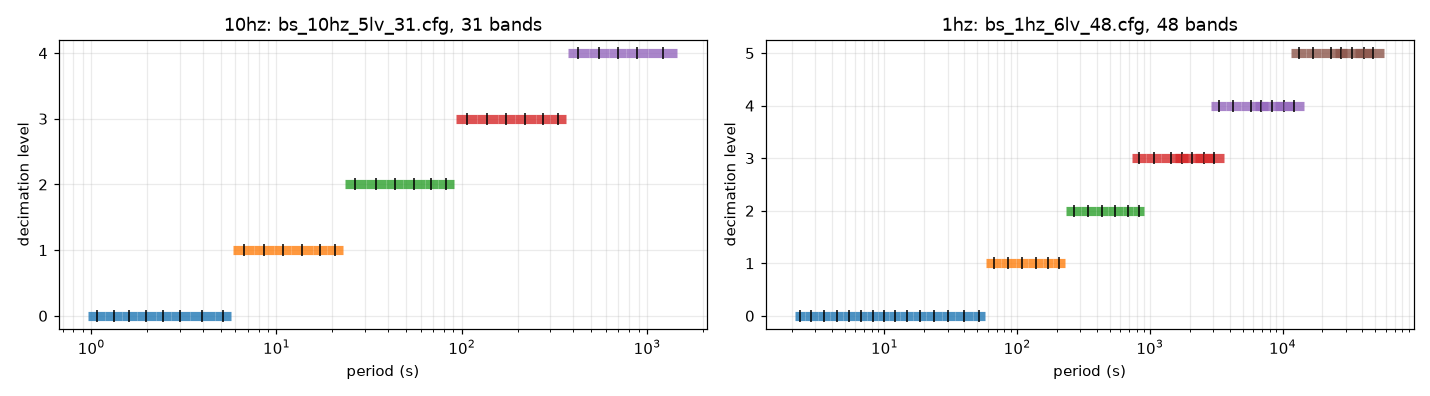


the Aurora parameter sets the package ships; kaiser20_75 is this run's
   dpss4_75       window_type=dpss, overlap=0.75, wargs={'NW': 4}
   kaiser20_50    window_type=kaiser, overlap=0.5, wargs={'beta': 20}
   kaiser20_75    window_type=kaiser, overlap=0.75, wargs={'beta': 20}
   kaiser20_w512  window_type=kaiser, overlap=0.75, wargs={'beta': 20}, window_samples=512

what the mask and the 3600 s run floor cost each site at 1 Hz


   Q82       {'site': 'Q82', 'days': 65.62, 'finite_frac': 1.0, 'H_intervals': 12, 'E_bursts': 67, 'kept_frac': 0.97069, 'runs': 51, 'floor_loss_frac': 0.00614, 'longest_run_d': 7.45}


   Q81N      {'site': 'Q81N', 'days': 65.79, 'finite_frac': 1.0, 'H_intervals': 501, 'E_bursts': 76, 'kept_frac': 0.92748, 'runs': 323, 'floor_loss_frac': 0.06714, 'longest_run_d': 1.33}


   Q80N      {'site': 'Q80N', 'days': 65.63, 'finite_frac': 1.0, 'H_intervals': 112, 'E_bursts': 59, 'kept_frac': 0.96604, 'runs': 136, 'floor_loss_frac': 0.00772, 'longest_run_d': 4.35}


   Q79N      {'site': 'Q79N', 'days': 65.64, 'finite_frac': 1.0, 'H_intervals': 40, 'E_bursts': 66, 'kept_frac': 0.98212, 'runs': 80, 'floor_loss_frac': 0.00635, 'longest_run_d': 7.11}


   Q78N      {'site': 'Q78N', 'days': 65.63, 'finite_frac': 1.0, 'H_intervals': 83, 'E_bursts': 83, 'kept_frac': 0.96826, 'runs': 119, 'floor_loss_frac': 0.01069, 'longest_run_d': 3.5}



site  days  finite_frac  H_intervals  E_bursts  kept_frac  runs  floor_loss_frac  longest_run_d
 Q82 65.62          1.0           12        67    0.97069    51          0.00614           7.45
Q81N 65.79          1.0          501        76    0.92748   323          0.06714           1.33
Q80N 65.63          1.0          112        59    0.96604   136          0.00772           4.35
Q79N 65.64          1.0           40        66    0.98212    80          0.00635           7.11
Q78N 65.63          1.0           83        83    0.96826   119          0.01069           3.50


In [11]:
tabs = {}
for key, bs in aurora_run.BANDS.items():
    tabs[key] = aurora_run.band_table(bs)
    print("%-5s %-22s %2d bands over %d levels, window %d samples, centres %.3f to %.1f s"
          % (key, bs.file.name, len(tabs[key]), tabs[key].level.nunique(), bs.window,
             tabs[key].centre_s.min(), tabs[key].centre_s.max()))
print()
key = "%dhz" % RATES[0]
print("the %s table, as Aurora computes it" % key)
print(tabs[key].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 3.6))
for ax, (k, tab) in zip(axes, sorted(tabs.items())):
    for r in tab.itertuples():
        ax.plot([r.lower_s, r.upper_s], [r.level, r.level], lw=6, solid_capstyle="butt",
                color="C%d" % (r.level % 10), alpha=0.8)
        ax.plot(r.centre_s, r.level, "k|", ms=8)
    ax.set(xscale="log", xlabel="period (s)", ylabel="decimation level",
           title="%s: %s, %d bands" % (k, aurora_run.BANDS[k].file.name, len(tab)),
           yticks=range(tab.level.nunique()))
    ax.grid(alpha=0.25, which="both")
fig.tight_layout()
bands_png = OUT / "03_bands.png"
fig.savefig(bands_png, dpi=110)
plt.close(fig)
WRITTEN.append(bands_png)
display(Image(filename=str(bands_png)))

print()
print("the Aurora parameter sets the package ships; %s is this run's" % PARAMS)
for name, p in sorted(aurora_run.AURORA_PARAMS.items()):
    print("   %-14s %s" % (name, ", ".join("%s=%s" % kv for kv in p.items())))
print()
print("what the mask and the %g s run floor cost each site at %g Hz" % (TR.MIN_SEGMENT_S, RATES[0]))
mask_rows = []
for s in CHOSEN:
    t0, arrays, meta = cache.load(s, WORK, RATES[0])
    d = sv.decision(s)
    arrays, _a, _u = FR.apply_signs(arrays, d)
    arrays, _ang = FR.rotate_to_mean_field(arrays, regimes=FR.parse_regimes(d.get("rot_regimes")),
                                           drop=FR.parse_regimes(d.get("rot_drop")), fs=float(RATES[0]))
    ev = TR.site_events(s, ALL_SITES, WORK, sv.cfg)
    ee = TR.e_events(s, WORK, sv.cfg)
    keep, stats = TR.build_keep(t0, {c: arrays[c] for c in mth5_build.LOCAL_CHANNELS}, float(RATES[0]),
                                ev, (), ee)
    runs = TR.segments(keep, int(TR.MIN_SEGMENT_S * RATES[0]))
    mask_rows.append(dict(site=s, days=round(stats["n"] / 86400.0 / RATES[0], 2),
                          finite_frac=stats["finite_frac"], H_intervals=len(ev), E_bursts=len(ee),
                          kept_frac=stats["kept_frac"], runs=len(runs),
                          floor_loss_frac=round(TR.floor_dropped_frac(keep, float(RATES[0])), 5),
                          longest_run_d=round(max((L for _o, L in runs), default=0) / 86400.0 / RATES[0], 2)))
    del arrays, keep
    print("   %-9s %s" % (s, mask_rows[-1]), flush=True)
mk = pd.DataFrame(mask_rows)
print()
print(mk.to_string(index=False))


## The MTH5

One site and one kind, written and read back. The MTH5 is what Aurora reads: the local station with its five
channels and, where there is a reference, a second station carrying hx and hy only on the same grid and with
the same run ids, so the kernel dataset's run-interval intersection pairs them one to one.

The channels carry nanoTesla and milliVolt per kilometer and no filter at all. The cache is already in
physical units, so a filter here would be applied a second time; the spelling of the units matters too,
because `millivolts per kilometer` resolves to `unknown per kilometer` in mt_metadata and writes the channel
with no unit.

**This check fails if the MTH5 differs from the cache sample for sample, or if its run count differs from the
kept stretches.** Every sample of every channel of every run is compared with the array it was written from.
The bound is 1e-3 nT and mV/km, which is the file's own float32 resolution at these levels.

In [12]:
probe_site = CHOSEN[0]                  # <- the first of the chosen set; any site answers the same question
probe_kind = "remote" if "remote" in KINDS else KINDS[0]
rate = RATES[0]
t0, arrays, meta = cache.load(probe_site, WORK, rate)
d = sv.decision(probe_site)
arrays, applied, undecided = FR.apply_signs(arrays, d)
arrays, ang = FR.rotate_to_mean_field(arrays, regimes=FR.parse_regimes(d.get("rot_regimes")),
                                      drop=FR.parse_regimes(d.get("rot_drop")), fs=float(rate))
local = {c: np.asarray(arrays[c], float) for c in mth5_build.LOCAL_CHANNELS}
rt0, rh, rmask, info = REF.load_reference(probe_kind, probe_site, rate, WORK)
ev = TR.site_events(probe_site, ALL_SITES, WORK, sv.cfg)
ee = TR.e_events(probe_site, WORK, sv.cfg)
ev_rem = [(pd.Timestamp(a).timestamp(), pd.Timestamp(b).timestamp())
          for a, b in (info.get("remote_events") or [])] if probe_kind == "remote" else []
keep, stats = TR.build_keep(t0, local, float(rate), ev, ev_rem, ee,
                            remote_mask=(None if rmask is None else rmask))
rid = REF.reference_station_id(probe_kind, info, OBS)
scratch = WORK / probe_site / "_mth5_check"
h5 = scratch / ("%s_%s.h5" % (probe_site, probe_kind))
t = time.time()
_p, segs = mth5_build.write_h5(h5, probe_site, local, (None if rh is None else (rid, rh)), t0, float(rate),
                               sv.cfg["name"], sv.site(probe_site), keep=keep,
                               reference_row=(sv.site(info["remote"]) if probe_kind == "remote" else None))
print("%s %s: %s written in %.1f s, %.1f MB" % (probe_site, probe_kind, h5.name, time.time() - t,
                                                h5.stat().st_size / 2 ** 20))
print("   stations  %s and %s" % (probe_site, rid or "none (single station)"))
print("   mask      keeps %.2f %% of %d samples; %d runs of at least %g s; the hour floor loses %.2f %% more"
      % (100 * stats["kept_frac"], stats["n"], len(segs), TR.MIN_SEGMENT_S,
         100 * TR.floor_dropped_frac(keep, float(rate))))
print("   runs      %s" % ", ".join("%03d %.2f d" % (i + 1, L / 86400.0 / rate)
                                    for i, (_o, L) in enumerate(segs[:12])))
back = mth5_build.read_back(h5, probe_site, local, segs, sv.cfg["name"])
print("   read back %s" % back)
n_kept_runs = len(TR.segments(keep, int(TR.MIN_SEGMENT_S * rate)))
left = mth5_build.remove(h5)          # a handle HDF5 has not released is said, not raised
if left:
    print("   %s" % left)
import shutil; shutil.rmtree(scratch, ignore_errors=True)
del arrays, local, rh

print()
if not back["samples_compared"]:
    print("VERDICT: UNJUDGED -- the MTH5 carried no sample to compare")
elif back["problems"] or back["runs_in_file"] != n_kept_runs:
    print("VERDICT: FAIL -- %d channel-runs differ from the cache (%s); the file holds %d runs where the "
          "mask leaves %d kept stretches of at least %g s"
          % (len(back["problems"]), "; ".join(back["problems"][:6]), back["runs_in_file"], n_kept_runs,
             TR.MIN_SEGMENT_S))
else:
    print("VERDICT: PASS -- %s's %s MTH5 carries all %d samples of its 5 channels over %d runs to within "
          "%.3g nT and mV/km of the rotated cache, and its run count is the %d kept stretches of at least "
          "%g s the mask leaves"
          % (probe_site, probe_kind, back["samples_compared"], back["runs_in_file"],
             back["worst_difference"], n_kept_runs, TR.MIN_SEGMENT_S))


Q82 remote: Q82_remote.h5 written in 26.0 s, 276.4 MB
   stations  Q82 and REMOTE_Q69N
   mask      keeps 90.80 % of 5670000 samples; 73 runs of at least 3600 s; the hour floor loses 0.71 % more
   runs      001 0.75 d, 002 0.19 d, 003 0.32 d, 004 0.18 d, 005 0.20 d, 006 0.15 d, 007 2.11 d, 008 2.21 d, 009 0.55 d, 010 0.09 d, 011 0.28 d, 012 0.19 d


   read back {'runs_in_file': 73, 'runs_written': 73, 'samples_compared': 25538370, 'worst_difference': 0.0, 'problems': []}

VERDICT: PASS -- Q82's remote MTH5 carries all 25538370 samples of its 5 channels over 73 runs to within 0 nT and mV/km of the rotated cache, and its run count is the 73 kept stretches of at least 3600 s the mask leaves


## The run

One subprocess per site, `LANES` of them at a time, each running
`python -m auslamp_proc.process.run` over that site's kinds and rates. A lane pins its BLAS threads to three:
a lane that takes every core makes three lanes slower than one, and the memory a pass peaks at is per lane.
Measured over the 115 products of AusLAMP Queensland Phase 1 on 2026-09-16, whose records run 12-62 days, a
1 Hz pass peaks at 2.5-4.8 GB and takes 140-912 s; the 15 products of the 10 Hz pass over the same records
peak at 22-37 GB and take 420-912 s. That is why `LANES` is 3 at 1 Hz and 1 at 10 Hz: three 10 Hz lanes
would want more than 100 GB.

The CLI is resumable by design. With `REDO` False a product whose EDI is already on disk is left alone and
reported as `exists`, so a run stopped part way is finished by re-running this cell. A product that fails is
caught, its error goes into its own ledger row, and the next product runs.

Each product writes `<site>_<kind>_<rate>hz_<params>.edi` and `.xml` into `<site>/<RUN>_<stamp>/`, beside
`log.txt` and `provenance.json`, and appends one row to `<work_root>/survey/runs.csv`.

**This check fails if any requested product is missing or FAILED in the ledger, or if any product lacks a
tipper, or if any provenance.json lacks the decisions.csv row it used.** The tipper is the third limb because
it comes out of the same pass as the impedance -- hz is in the local station -- so a product without one was
run on a record missing its vertical channel.

In [13]:
import subprocess
import concurrent.futures as cf

ENV = dict(os.environ)
ENV.update(OMP_NUM_THREADS="3", MKL_NUM_THREADS="3", OPENBLAS_NUM_THREADS="3")   # <- 3 threads a lane

def one_site(site):
    cmd = [sys.executable, "-m", "auslamp_proc.process.run", "--survey", SURVEY, "--site", site,
           "--run", RUN, "--stamp", STAMP, "--params", PARAMS, "--quiet",
           "--kinds"] + list(KINDS) + ["--rates"] + [str(r) for r in RATES]
    if REDO:
        cmd.append("--redo")
    if WORK_ROOT:
        cmd += ["--work-root", str(WORK_ROOT)]
    t = time.time()
    r = subprocess.run(cmd, cwd=str(REPO), capture_output=True, text=True, env=ENV)
    return site, r.returncode, round(time.time() - t, 1), (r.stdout or "").strip()[-300:], \
        (r.stderr or "").strip()[-400:]

t_run = time.time()
print("%d site(s) in %d lane(s), %d kind(s) at %s Hz -> %s_%s"
      % (len(CHOSEN), LANES, len(KINDS), ", ".join(str(r) for r in RATES), RUN, STAMP), flush=True)
done = 0
with cf.ThreadPoolExecutor(max_workers=LANES) as ex:
    for site, rc, secs, out, err in ex.map(one_site, CHOSEN):
        done += 1
        print("%2d/%2d %-9s exit %d %7.1f s  %s%s" % (done, len(CHOSEN), site, rc, secs, out,
                                                      ("  || " + err) if rc else ""), flush=True)
wall = time.time() - t_run
print()
print("wall time %.1f min over %d sites in %d lanes; a resumed run finds its products on disk and this is "
      "the time to check them, not the time they cost" % (wall / 60.0, len(CHOSEN), LANES))

ledger = pd.read_csv(WORK / "survey" / "runs.csv")
led = ledger[(ledger["stamp"].astype(str) == STAMP) & (ledger.site.isin(CHOSEN))].copy()
# runs.csv is append-only, so re-running this workbook adds an `exists` row beside the `made` row of the
# same product. The row that says what a product cost is the one written when it was made, so that row
# wins and one row per product is kept.
led["_made"] = (led.status == "made").astype(int)
led = (led.sort_values(["site", "kind", "rate_hz", "_made"])
       .drop_duplicates(["site", "kind", "rate_hz"], keep="last").drop(columns="_made"))
print()
print(led[["site", "kind", "rate_hz", "params", "remote", "n_runs", "mask_dropped_frac",
           "floor_dropped_frac", "seconds", "peak_rss_mb", "status", "error"]].to_string(index=False))
print()
print("per kind")
print(led.groupby("kind").agg(products=("status", "size"), made=("status", lambda v: int((v == "made").sum())),
                              failed=("status", lambda v: int((v == "FAILED").sum())),
                              seconds=("seconds", "median"),
                              peak_rss_mb=("peak_rss_mb", "max")).to_string())

want = [(s, k, float(r)) for s in CHOSEN for k in KINDS for r in RATES]
have = {(r.site, r.kind, float(r.rate_hz)): r for r in led.itertuples()}
missing = [w for w in want if w not in have]
failed = led[led.status == "FAILED"]
no_tipper, no_prov = [], []
for w in want:
    r = have.get(w)
    if r is None or str(r.status) == "FAILED":
        continue
    p = Path(str(r.edi))
    if not p.exists():
        missing.append(w)
        continue
    if not EDI.has_tipper(p):
        no_tipper.append("%s %s %g Hz" % w)
for s in sorted({w[0] for w in want}):
    pj = WORK / s / ("%s_%s" % (RUN, STAMP)) / "provenance.json"
    d = PROV.read(pj)
    if not d or not d.get("decisions_row") or not d["decisions_row"].get("site"):
        no_prov.append(s)
print()
if not want:
    print("VERDICT: UNJUDGED -- no product was requested")
elif missing or len(failed) or no_tipper or no_prov:
    print("VERDICT: FAIL -- %d of %d requested products are missing (%s); %d are FAILED in the ledger (%s); "
          "%d carry no tipper (%s); %d of %d provenance files lack the decisions.csv row (%s)"
          % (len(missing), len(want), "; ".join("%s %s %g Hz" % m for m in missing[:8]) or "none",
             len(failed), "; ".join("%s %s: %s" % (r.site, r.kind, str(r.error)[:80])
                                    for r in failed.itertuples()) or "none",
             len(no_tipper), "; ".join(no_tipper[:8]) or "none",
             len(no_prov), len(CHOSEN), ", ".join(no_prov) or "none"))
else:
    print("VERDICT: PASS -- all %d requested products exist and none is FAILED (%d made, %d already on "
          "disk), every one carries a tipper, and all %d provenance files name the decisions.csv row they "
          "used; this execution took %.1f min, the products cost %.1f machine-minutes between them, and the "
          "largest peak was %.0f MB in one lane"
          % (len(want), int((led.status == "made").sum()), int((led.status == "exists").sum()),
             len(CHOSEN), wall / 60.0, led.seconds.sum() / 60.0, led.peak_rss_mb.max()))


5 site(s) in 3 lane(s), 5 kind(s) at 1 Hz -> first_20260916_1056


 1/ 5 Q82       exit 0     3.2 s  {"site": "Q82", "made": 0, "exists": 5, "failed": 0}


 2/ 5 Q81N      exit 0     3.1 s  {"site": "Q81N", "made": 0, "exists": 5, "failed": 0}


 3/ 5 Q80N      exit 0     3.3 s  {"site": "Q80N", "made": 0, "exists": 5, "failed": 0}


 4/ 5 Q79N      exit 0     3.1 s  {"site": "Q79N", "made": 0, "exists": 5, "failed": 0}


 5/ 5 Q78N      exit 0     3.0 s  {"site": "Q78N", "made": 0, "exists": 5, "failed": 0}



wall time 0.1 min over 5 sites in 3 lanes; a resumed run finds its products on disk and this is the time to check them, not the time they cost

site      kind  rate_hz      params      remote  n_runs  mask_dropped_frac  floor_dropped_frac  seconds  peak_rss_mb status  error
Q78N       obs      1.0 kaiser20_75     OBS_CTA   121.0            0.03183             0.01069    343.6       4998.4   made    NaN
Q78N    remote      1.0 kaiser20_75 REMOTE_Q79N   150.0            0.03796             0.01206    444.8       4960.8   made    NaN
Q78N    single      1.0 kaiser20_75         NaN   119.0            0.03174             0.01069    269.5       3924.4   made    NaN
Q78N     stack      1.0 kaiser20_75       STACK   119.0            0.03352             0.01069    369.8       4993.0   made    NaN
Q78N stack_obs      1.0 kaiser20_75   STACK_OBS   119.0            0.03174             0.01069    334.0       5004.6   made    NaN
Q79N       obs      1.0 kaiser20_75     OBS_CTA    82.0            0.

## A first look

One line per site and kind at 100-1000 s: the two apparent resistivities, the two phases and the tipper
magnitude, read straight out of the EDI. Under it, the single station against the remote site as a ratio at
10-100 s and at 100-1000 s, which is what the reference bought at each end.

This is a reading and not a check. A single station biased down by H noise coherent with itself shows as a
ratio below one; a remote that shares the target's noise shows as a ratio near one where the single station
is known to be biased. The full figures, every product on one page, are workbook 04's.

In [14]:
from mt_metadata.transfer_functions.core import TF

def read_product(path):
    tf = TF(fn=str(path))
    tf.read()
    p = np.asarray(tf.period, float)
    z = np.asarray(tf.impedance, complex)
    t = np.asarray(tf.tipper, complex) if tf.tipper is not None else None
    return p, z, t

def band_read(p, z, t, lo, hi):
    m = (p >= lo) & (p <= hi)
    if not m.any():
        return {}
    out = {}
    for name, (i, j) in (("xy", (0, 1)), ("yx", (1, 0))):
        zz = z[m, i, j]
        good = np.isfinite(zz) & (np.abs(zz) > 0)
        if not good.any():
            continue
        rho = 0.2 * p[m][good] * np.abs(zz[good]) ** 2
        ph = np.degrees(np.angle(zz[good]))
        out["rho_%s" % name] = float(np.median(rho))
        out["phase_%s" % name] = float(np.median(ph))
    if t is not None and np.isfinite(t[m]).any():
        out["tipper"] = float(np.nanmedian(np.abs(t[m]).max(axis=-1)))
    return out

look_rows = []
for r in led.itertuples():
    p_ = Path(str(r.edi))
    if not p_.exists():
        continue
    try:
        per, z, tp = read_product(p_)
        row = dict(site=r.site, kind=r.kind, rate_hz=r.rate_hz, periods=len(per),
                   shortest_s=round(float(np.min(per)), 3), longest_s=round(float(np.max(per)), 1))
        row.update({k: round(v, 3) for k, v in band_read(per, z, tp, 100.0, 1000.0).items()})
        for k, v in band_read(per, z, tp, 10.0, 100.0).items():
            row["%s_10_100" % k] = round(v, 3)
    except Exception as exc:
        row = dict(site=r.site, kind=r.kind, rate_hz=r.rate_hz,
                   note="%s: %s" % (type(exc).__name__, str(exc)[:60]))
    look_rows.append(row)
first = pd.DataFrame(look_rows)
print("the reading at 100-1000 s, per site and kind")
print(first.to_string(index=False))

if "single" in KINDS and "remote" in KINDS:
    piv = first.pivot_table(index="site", columns="kind",
                            values=["rho_xy", "rho_yx", "rho_xy_10_100", "rho_yx_10_100"])
    ratio_rows = []
    for s in sorted(set(first.site)):
        row = dict(site=s)
        for col, label in (("rho_xy_10_100", "xy 10-100 s"), ("rho_yx_10_100", "yx 10-100 s"),
                           ("rho_xy", "xy 100-1000 s"), ("rho_yx", "yx 100-1000 s")):
            try:
                a = piv.loc[s, (col, "single")]
                b = piv.loc[s, (col, "remote")]
                row[label] = round(float(a / b), 3) if np.isfinite(a) and np.isfinite(b) and b else np.nan
            except KeyError:
                row[label] = np.nan
        ratio_rows.append(row)
    print()
    print("single station over remote site, as a ratio of apparent resistivity")
    print(pd.DataFrame(ratio_rows).to_string(index=False))


the reading at 100-1000 s, per site and kind
site      kind  rate_hz  periods  shortest_s  longest_s  rho_xy  phase_xy   rho_yx  phase_yx  tipper  rho_xy_10_100  phase_xy_10_100  rho_yx_10_100  phase_yx_10_100  tipper_10_100
Q78N       obs      1.0       48       2.303    48470.4  61.424    27.951   60.567  -156.286   0.226          9.094            8.055         11.123         -167.502          0.066
Q78N    remote      1.0       41       2.303    12117.6  61.695    27.809   60.773  -156.355   0.226          9.070            7.990         11.134         -167.603          0.065
Q78N    single      1.0       48       2.303    48470.4  61.574    27.833   60.600  -156.364   0.226          8.931            7.836         10.465         -167.631          0.088
Q78N     stack      1.0       48       2.303    48470.4  61.701    27.838   60.708  -156.341   0.228          9.072            8.025         11.129         -167.594          0.065
Q78N stack_obs      1.0       48       2.303    48470.4

## What was written

In [15]:
rows = []
run_dirs = [WORK / s / ("%s_%s" % (RUN, STAMP)) for s in CHOSEN]
for d in run_dirs:
    for p in sorted(d.glob("*")):
        if p.is_file():
            rows.append(dict(file=str(p), kb=round(p.stat().st_size / 1024, 1)))
for rate in RATES:
    for p in sorted((WORK / "references" / ("%dhz" % rate)).glob("*")):
        rows.append(dict(file=str(p), kb=round(p.stat().st_size / 1024, 1)))
for p in sorted(TR.tails_dir(WORK).glob("*.npz")):
    rows.append(dict(file=str(p), kb=round(p.stat().st_size / 1024, 1)))
for p in list(WRITTEN) + [WORK / "survey" / "runs.csv"]:
    if Path(p).exists():
        rows.append(dict(file=str(p), kb=round(Path(p).stat().st_size / 1024, 1)))
files = pd.DataFrame(rows).drop_duplicates("file").sort_values("file")
print("%d files, %.1f MB" % (len(files), files.kb.sum() / 1024))
print(files.head(60).to_string(index=False))
if len(files) > 60:
    print("   ... and %d more" % (len(files) - 60))
print()
d = run_dirs[0]
print("the run folder of %s" % CHOSEN[0])
for p in sorted(d.glob("*")):
    print("   %-52s %8.1f KB" % (p.name, p.stat().st_size / 1024))
print()
print("the first 30 processing_parameters lines of one EDI")
one = sorted(d.glob("*.edi"))
if one:
    txt = one[0].read_text(encoding="utf-8", errors="ignore")
    keep_lines = [ln.strip() for ln in txt.splitlines()
                  if "=" in ln and not ln.strip().startswith(">")]
    print(one[0].name)
    for ln in keep_lines[:30]:
        print("   %s" % ln[:160])


124 files, 980.2 MB
                                                                                                                 file   kb
      E:\MT_Timeseries_DATA\MT_AusLAMP_QLD\Processing_WB\phase2\Q78N\first_20260916_1056\Q78N_obs_1hz_kaiser20_75.edi 26.2
      E:\MT_Timeseries_DATA\MT_AusLAMP_QLD\Processing_WB\phase2\Q78N\first_20260916_1056\Q78N_obs_1hz_kaiser20_75.xml 71.5
   E:\MT_Timeseries_DATA\MT_AusLAMP_QLD\Processing_WB\phase2\Q78N\first_20260916_1056\Q78N_remote_1hz_kaiser20_75.edi 24.2
   E:\MT_Timeseries_DATA\MT_AusLAMP_QLD\Processing_WB\phase2\Q78N\first_20260916_1056\Q78N_remote_1hz_kaiser20_75.xml 62.0
   E:\MT_Timeseries_DATA\MT_AusLAMP_QLD\Processing_WB\phase2\Q78N\first_20260916_1056\Q78N_single_1hz_kaiser20_75.edi 26.1
   E:\MT_Timeseries_DATA\MT_AusLAMP_QLD\Processing_WB\phase2\Q78N\first_20260916_1056\Q78N_single_1hz_kaiser20_75.xml 71.5
    E:\MT_Timeseries_DATA\MT_AusLAMP_QLD\Processing_WB\phase2\Q78N\first_20260916_1056\Q78N_stack_1hz_kaiser20_75.edi 2